<a href="https://colab.research.google.com/github/rsiyanwal/Machine-Learning-From-Scratch/blob/main/patterns_curriculum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desperately Seeking Patterns
## A Tutorial Curriculum on Finding Patterns in Data

> *"Newly hatched ducklings must have the ability to make out or tell apart the properties of things they see moving around them."*  
> — *Why Machines Learn*, Ch. 1

This curriculum trains your eye — and your mind — to find patterns everywhere: in number tables, in images, in real-life data. That skill is the beating heart of machine learning.

---

### What You Will Build
| Module | Topic | What You'll Do |
|--------|-------|----------------|
| 1 | Patterns are Everywhere | Spot patterns in sequences, shapes, and daily life |
| 2 | Patterns in Tables | Find hidden formulas in data tables |
| 3 | Patterns in Graphs | Read the story a scatter plot is telling you |
| 4 | Patterns in Images | How pixels encode visual structure |
| 5 | Patterns with Multiple Features | When one variable isn't enough |
| 6 | Linear Patterns & Weights | The math that captures a pattern |
| 7 | Drawing the Boundary | Classify with a line |
| 8 | When Patterns Hide | Noise, outliers, and harder cases |

**Prerequisites:** Basic Python. No ML knowledge required.


In [24]:
# Run this first — installs and imports everything the curriculum needs
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print("✓ Ready. Let's find some patterns.")


✓ Ready. Let's find some patterns.


---
## Module 1: Patterns Are Everywhere

Before we touch data tables or code, let's train the most important skill: **noticing**.

A pattern is anything that repeats, continues, or connects in a predictable way.

### 1.1 Number Sequences — What comes next?

Look at each row. Don't calculate — just *feel* the rhythm first.

```
2,  4,  6,  8,  ___        (hint: counting by 2s)
1,  3,  9,  27, ___        (hint: something is multiplying)
1,  1,  2,  3,  5,  8, ___ (hint: add the previous two)
100, 50, 25, 12.5, ___     (hint: something is dividing)
0,  1,  4,  9,  16, ___    (hint: these are perfect squares)
```

**Exercise 1.1:** Fill in the blanks. Then write, in one sentence, the rule behind each sequence.


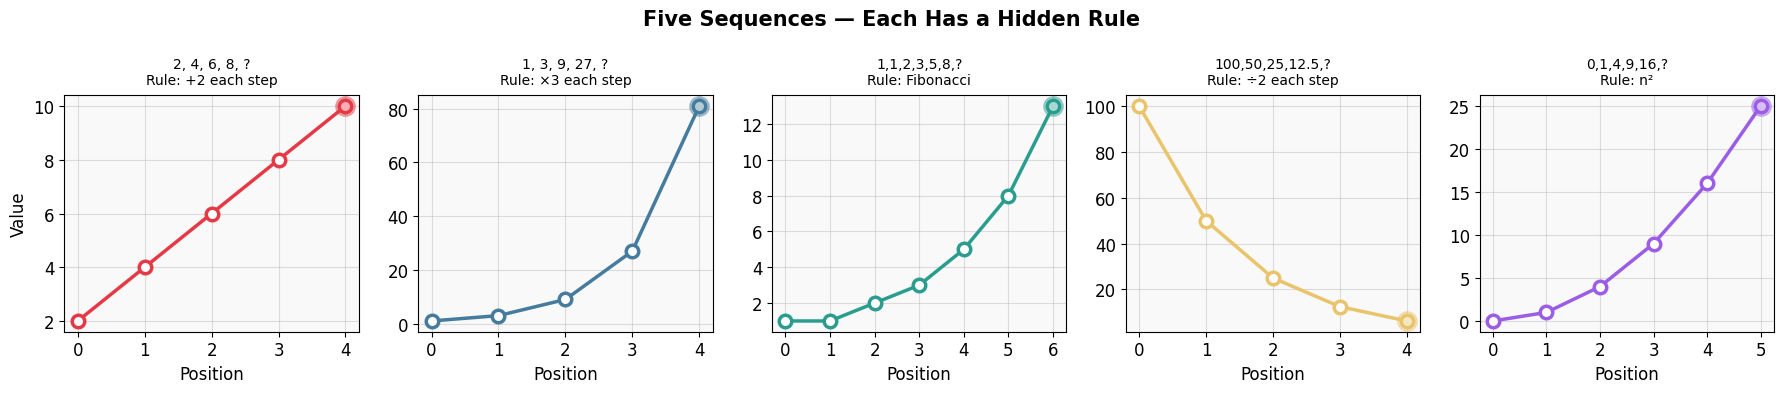

The shaded dot is the answer — notice the shape of each curve. Linear? Exponential? Parabolic?


In [25]:
# Visual: See all five sequences plotted side by side
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Five Sequences — Each Has a Hidden Rule", fontsize=15, fontweight='bold')

sequences = [
    ([2, 4, 6, 8, 10], "2, 4, 6, 8, ?\nRule: +2 each step"),
    ([1, 3, 9, 27, 81], "1, 3, 9, 27, ?\nRule: ×3 each step"),
    ([1, 1, 2, 3, 5, 8, 13], "1,1,2,3,5,8,?\nRule: Fibonacci"),
    ([100, 50, 25, 12.5, 6.25], "100,50,25,12.5,?\nRule: ÷2 each step"),
    ([0, 1, 4, 9, 16, 25], "0,1,4,9,16,?\nRule: n²"),
]
colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#9b5de5']

for ax, (seq, label), color in zip(axes, sequences, colors):
    ax.plot(range(len(seq)), seq, 'o-', color=color, linewidth=2.5,
            markersize=9, markerfacecolor='white', markeredgewidth=2.5)
    # Highlight the last point as "the answer"
    ax.plot(len(seq)-1, seq[-1], 'o', color=color, markersize=14, alpha=0.4)
    ax.set_title(label, fontsize=10, pad=8)
    ax.set_xlabel("Position")
    ax.set_xticks(range(len(seq)))

axes[0].set_ylabel("Value")
plt.tight_layout()
plt.show()
print("The shaded dot is the answer — notice the shape of each curve. Linear? Exponential? Parabolic?")


### How to read the four plots you just saw

- **Strong positive:** the cloud rises from left to right and stays fairly close to a line.
- **Weak positive:** the cloud still rises overall, but the spread is much wider, so predictions are less certain.
- **Negative relationship:** larger x tends to come with smaller y, so the cloud slopes downward.
- **No relationship:** the points do not organize around any direction; knowing x tells you almost nothing about y.

A machine learning model is trying to detect exactly these kinds of regularities. The first skill is not fitting a line — it is recognizing whether a line-like pattern exists in the first place.


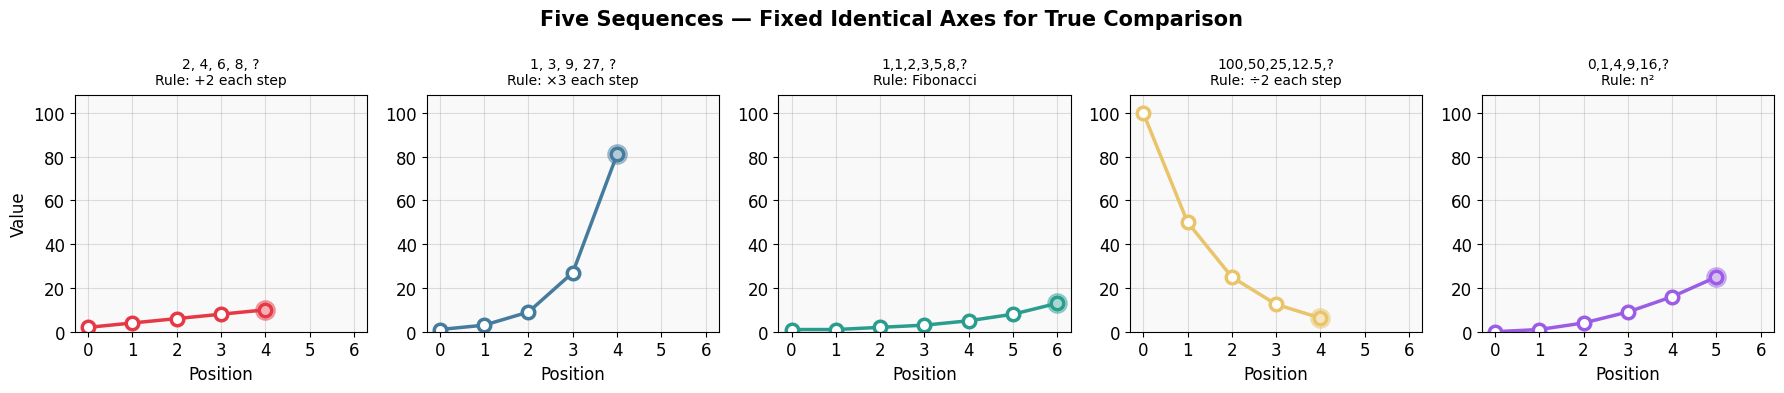

Every subplot shares the same x-range (0 – 6) and y-range (0 – 108).

What the fixed axes reveal:
  ÷2  (halving)   → starts at 100, plunges immediately — dominates the top of the chart
  ×3  (geometric) → rockets to 81 — steeply exponential
  n²  (square)    → gentle parabola, only reaches 25
  Fib (Fibonacci) → modest climb to 13
  +2  (linear)    → nearly FLAT at the bottom, barely reaching 10

With auto-scaled axes each curve 'fills' its own subplot, making them look
deceptively similar in shape. Fixed axes show the truth: growth rates differ
by an order of magnitude across these five simple rules.


In [26]:
# Visual: See all five sequences plotted side by side — FIXED identical axes
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Five Sequences — Fixed Identical Axes for True Comparison", fontsize=15, fontweight='bold')

sequences = [
    ([2, 4, 6, 8, 10],       "2, 4, 6, 8, ?\nRule: +2 each step"),
    ([1, 3, 9, 27, 81],      "1, 3, 9, 27, ?\nRule: ×3 each step"),
    ([1, 1, 2, 3, 5, 8, 13], "1,1,2,3,5,8,?\nRule: Fibonacci"),
    ([100, 50, 25, 12.5, 6.25], "100,50,25,12.5,?\nRule: ÷2 each step"),
    ([0, 1, 4, 9, 16, 25],   "0,1,4,9,16,?\nRule: n²"),
]
colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#9b5de5']

# ── Compute shared axis bounds across ALL sequences ──────────────────────────
all_values  = [v for seq, _ in sequences for v in seq]
global_xmax = max(len(seq) for seq, _ in sequences) - 1  # 6  (Fibonacci: 7 pts)
global_ymin = 0
global_ymax = max(all_values) * 1.08                     # 108 — headroom above 100

for ax, (seq, label), color in zip(axes, sequences, colors):
    positions = range(len(seq))
    ax.plot(positions, seq, 'o-', color=color, linewidth=2.5,
            markersize=9, markerfacecolor='white', markeredgewidth=2.5)
    # Highlight the last point as "the answer"
    ax.plot(len(seq) - 1, seq[-1], 'o', color=color, markersize=14, alpha=0.4)
    ax.set_title(label, fontsize=10, pad=8)
    ax.set_xlabel("Position")

    # ── Every subplot gets the SAME x and y range ───────────────────────────
    ax.set_xlim(-0.3, global_xmax + 0.3)
    ax.set_ylim(global_ymin, global_ymax)
    ax.set_xticks(range(global_xmax + 1))

axes[0].set_ylabel("Value")
plt.tight_layout()
plt.show()

print("Every subplot shares the same x-range (0 – 6) and y-range (0 – 108).")
print()
print("What the fixed axes reveal:")
print("  ÷2  (halving)   → starts at 100, plunges immediately — dominates the top of the chart")
print("  ×3  (geometric) → rockets to 81 — steeply exponential")
print("  n²  (square)    → gentle parabola, only reaches 25")
print("  Fib (Fibonacci) → modest climb to 13")
print("  +2  (linear)    → nearly FLAT at the bottom, barely reaching 10")
print()
print("With auto-scaled axes each curve 'fills' its own subplot, making them look")
print("deceptively similar in shape. Fixed axes show the truth: growth rates differ")
print("by an order of magnitude across these five simple rules.")

### 1.2 Patterns in Real Life — Before You See the Numbers

The key habit of a data scientist: **look at the world and ask "what varies, and what does it depend on?"**

Here are five real-world situations. For each, guess: does a pattern exist? What would it look like?

| Situation | Your guess: Is there a pattern? | What depends on what? |
|-----------|--------------------------------|-----------------------|
| The taller a person, the heavier they are | | |
| More hours of sunlight → more ice cream sold | | |
| Number of bedrooms → house price | | |
| Student's study hours → exam score | | |
| City altitude → average temperature | | |

**The point:** You already have pattern-seeking intuitions. Machine learning formalizes them.


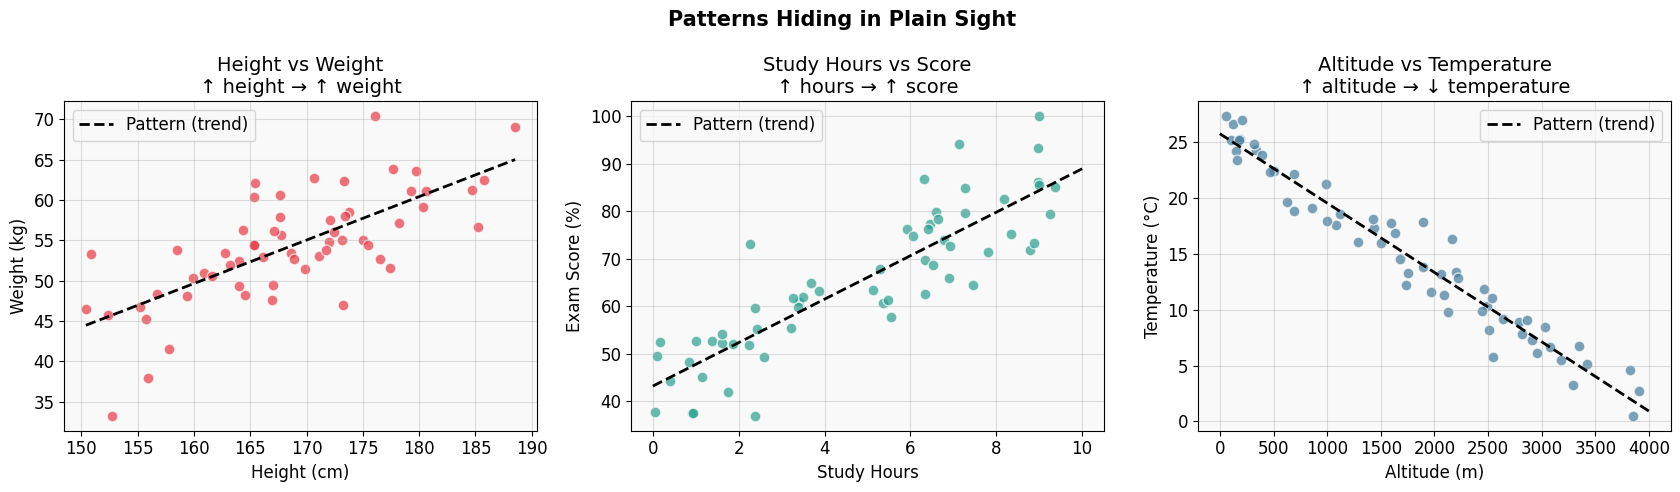

Notice: the dashed line captures the pattern — it ignores the noise and shows the relationship.


In [27]:
# Let's reveal those real-world patterns visually
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Patterns Hiding in Plain Sight", fontsize=15, fontweight='bold')

# --- Height vs Weight ---
height = np.random.normal(170, 10, 60)
weight = 0.5 * height - 30 + np.random.normal(0, 5, 60)
axes[0].scatter(height, weight, color='#e63946', alpha=0.7, s=60, edgecolors='white')
m, b = np.polyfit(height, weight, 1)
x_line = np.linspace(height.min(), height.max(), 100)
axes[0].plot(x_line, m * x_line + b, 'k--', linewidth=2, label='Pattern (trend)')
axes[0].set_xlabel("Height (cm)")
axes[0].set_ylabel("Weight (kg)")
axes[0].set_title("Height vs Weight\n↑ height → ↑ weight")
axes[0].legend()

# --- Study Hours vs Exam Score ---
hours = np.random.uniform(0, 10, 60)
score = 40 + 5 * hours + np.random.normal(0, 8, 60)
score = np.clip(score, 0, 100)
axes[1].scatter(hours, score, color='#2a9d8f', alpha=0.7, s=60, edgecolors='white')
m2, b2 = np.polyfit(hours, score, 1)
x2 = np.linspace(0, 10, 100)
axes[1].plot(x2, m2 * x2 + b2, 'k--', linewidth=2, label='Pattern (trend)')
axes[1].set_xlabel("Study Hours")
axes[1].set_ylabel("Exam Score (%)")
axes[1].set_title("Study Hours vs Score\n↑ hours → ↑ score")
axes[1].legend()

# --- Altitude vs Temperature ---
altitude = np.random.uniform(0, 4000, 60)
temp = 25 - 0.006 * altitude + np.random.normal(0, 2, 60)
axes[2].scatter(altitude, temp, color='#457b9d', alpha=0.7, s=60, edgecolors='white')
m3, b3 = np.polyfit(altitude, temp, 1)
x3 = np.linspace(0, 4000, 100)
axes[2].plot(x3, m3 * x3 + b3, 'k--', linewidth=2, label='Pattern (trend)')
axes[2].set_xlabel("Altitude (m)")
axes[2].set_ylabel("Temperature (°C)")
axes[2].set_title("Altitude vs Temperature\n↑ altitude → ↓ temperature")
axes[2].legend()

plt.tight_layout()
plt.show()
print("Notice: the dashed line captures the pattern — it ignores the noise and shows the relationship.")


---
## Module 2: Patterns in Tables

This is the exact exercise from *Why Machines Learn* — but we'll push it further.

### 2.1 The Book's Example

Look at this table. **Don't read ahead.** Stare at it. What connects x1, x2, and y?

| x1 | x2 | y  |
|----|----|----|
| 4  | 2  | 8  |
| 1  | 2  | 5  |
| 0  | 5  | 10 |
| 2  | 1  | 4  |

Spend 60 seconds. Write down your guess before running the next cell.


In [28]:
# Reveal: verify the pattern y = x1 + 2*x2
data = [(4,2,8), (1,2,5), (0,5,10), (2,1,4)]

print("=" * 50)
print("  x1   x2    y    x1 + 2×x2   Match?")
print("=" * 50)
for x1, x2, y in data:
    predicted = x1 + 2*x2
    match = "✓" if predicted == y else "✗"
    print(f"   {x1}    {x2}    {y}      {predicted}         {match}")
print("=" * 50)
print("\nThe hidden pattern:  y = x1 + 2×x2")
print("In ML language:      y = w1·x1 + w2·x2  where w1=1, w2=2")
print("\nThose constants (1 and 2) are called WEIGHTS.")
print("Finding them IS machine learning.")


  x1   x2    y    x1 + 2×x2   Match?
   4    2    8      8         ✓
   1    2    5      5         ✓
   0    5    10      10         ✓
   2    1    4      4         ✓

The hidden pattern:  y = x1 + 2×x2
In ML language:      y = w1·x1 + w2·x2  where w1=1, w2=2

Those constants (1 and 2) are called WEIGHTS.
Finding them IS machine learning.


### 2.2 Pattern Hunt — Three More Tables

Each table below has a hidden rule. Find it. There's one rule per table.

**Table A**
| x1 | x2 | y  |
|----|----|----|
| 3  | 1  | 7  |
| 2  | 4  | 12 |
| 5  | 0  | 10 |
| 1  | 3  | 8  |

**Table B** *(harder — there's a constant involved)*
| x1 | x2 | y  |
|----|----|----|
| 2  | 3  | 11 |
| 1  | 1  | 5  |
| 4  | 2  | 14 |
| 0  | 5  | 13 |

**Table C** *(only one input matters)*
| x1 | x2 | y  |
|----|----|----|
| 7  | 2  | 21 |
| 3  | 9  | 9  |
| 5  | 1  | 15 |
| 2  | 7  | 6  |

**Exercise 2.2:** Write your guessed formula in the cell below, then run the checker.


In [29]:
def check_formula(table_name, data, formula_fn):
    print(f"\n--- {table_name} ---")
    print(f"  x1   x2    y   predicted  match?")
    all_correct = True
    for x1, x2, y in data:
        pred = formula_fn(x1, x2)
        ok = "✓" if abs(pred - y) < 0.001 else "✗"
        if ok == "✗": all_correct = False
        print(f"   {x1}    {x2}    {y}     {pred}        {ok}")
    print("  → All correct!" if all_correct else "  → Not quite — try a different formula.")

# Table A: y = 2*x1 + x2
table_A = [(3,1,7), (2,4,12), (5,0,10), (1,3,8)]
check_formula("Table A", table_A, lambda x1, x2: 2*x1 + x2)

# Table B: y = 2*x1 + x2 + b — change b until it works
# Hint: the rule is  y = 2*x1 + 3*x2 - 1  (nope, try it)
# Answer:            y = 2*x1 + 3*x2 - 1
table_B = [(2,3,11), (1,1,5), (4,2,14), (0,5,13)]
check_formula("Table B", table_B, lambda x1, x2: 2*x1 + 3*x2 - 1)

# Table C: y = 3*x1 (x2 is a red herring!)
table_C = [(7,2,21), (3,9,9), (5,1,15), (2,7,6)]
check_formula("Table C", table_C, lambda x1, x2: 3*x1)



--- Table A ---
  x1   x2    y   predicted  match?
   3    1    7     7        ✓
   2    4    12     8        ✗
   5    0    10     10        ✓
   1    3    8     5        ✗
  → Not quite — try a different formula.

--- Table B ---
  x1   x2    y   predicted  match?
   2    3    11     12        ✗
   1    1    5     4        ✗
   4    2    14     13        ✗
   0    5    13     14        ✗
  → Not quite — try a different formula.

--- Table C ---
  x1   x2    y   predicted  match?
   7    2    21     21        ✓
   3    9    9     9        ✓
   5    1    15     15        ✓
   2    7    6     6        ✓
  → All correct!


**Key insight from Table C:** Not all features matter. x2 was a *distractor*. In real ML problems, figuring out which inputs actually carry information is half the battle.

---
## Module 3: Patterns in Graphs

A scatter plot is a detective's canvas. Let's learn to read it.

### 3.1 The Four Relationships

Every scatter plot tells one of four stories about the relationship between two variables.

Before you look at the plots, ask the same four questions every time:

1. **Direction:** As x increases, does y tend to go up, go down, or do nothing clear?
2. **Strength:** Do the points hug a line tightly, or are they spread out loosely?
3. **Shape:** Is the pattern straight, curved, clustered, or random?
4. **Exceptions:** Are there outliers or strange points that break the rule?

That habit — not just seeing a graph, but narrating what it says — is exactly what good data analysis begins with.


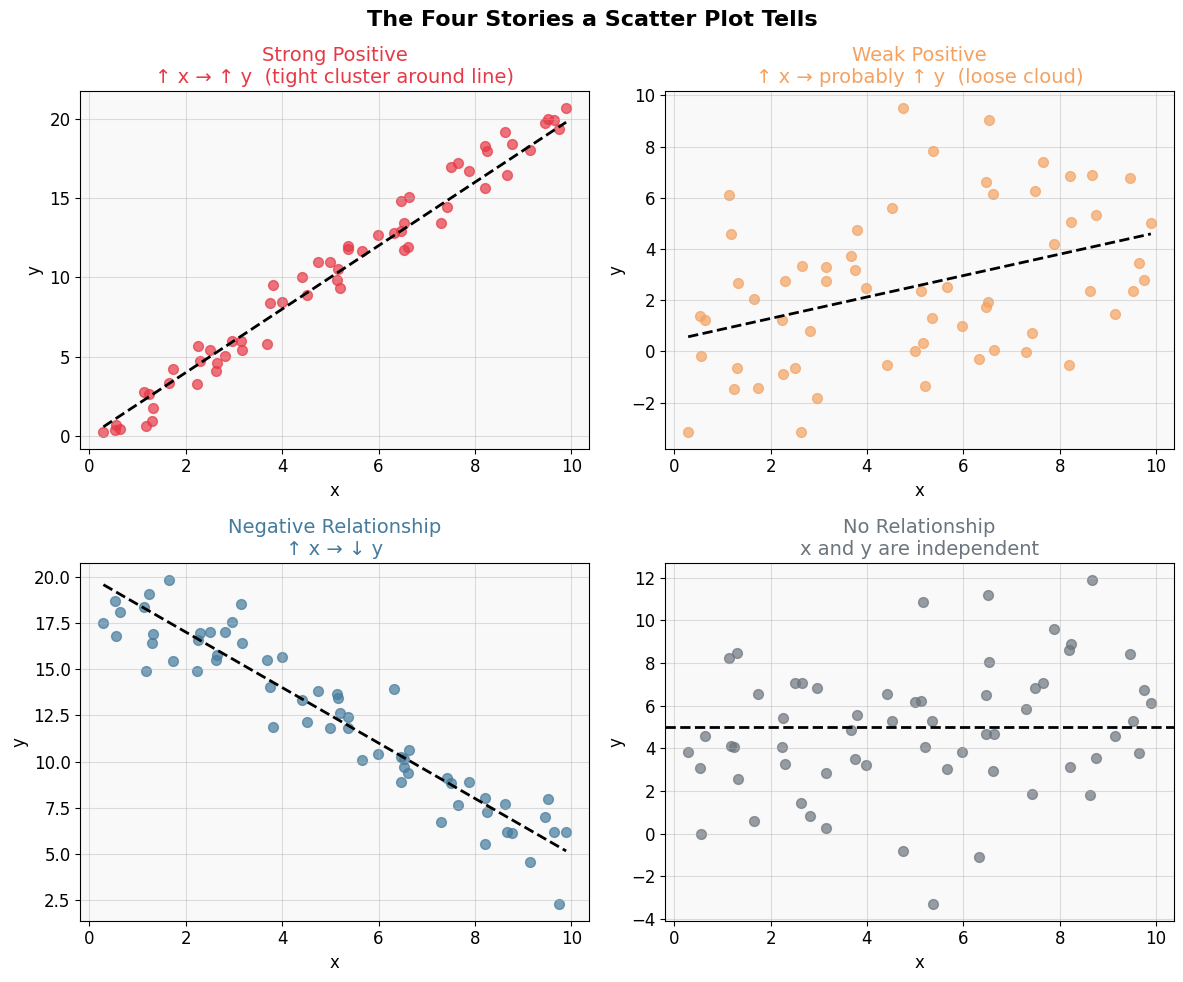

In [30]:
np.random.seed(0)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("The Four Stories a Scatter Plot Tells", fontsize=16, fontweight='bold')

x = np.linspace(0, 10, 60) + np.random.normal(0, 0.3, 60)

# Strong positive
y1 = 2*x + np.random.normal(0, 1, 60)
axes[0,0].scatter(x, y1, color='#e63946', alpha=0.7, s=50)
axes[0,0].plot(np.sort(x), 2*np.sort(x), 'k--', lw=2)
axes[0,0].set_title("Strong Positive\n↑ x → ↑ y  (tight cluster around line)", color='#e63946')
axes[0,0].set_xlabel("x"); axes[0,0].set_ylabel("y")

# Weak positive
y2 = 0.5*x + np.random.normal(0, 3, 60)
axes[0,1].scatter(x, y2, color='#f4a261', alpha=0.7, s=50)
m,b = np.polyfit(x, y2, 1)
axes[0,1].plot(np.sort(x), m*np.sort(x)+b, 'k--', lw=2)
axes[0,1].set_title("Weak Positive\n↑ x → probably ↑ y  (loose cloud)", color='#f4a261')
axes[0,1].set_xlabel("x"); axes[0,1].set_ylabel("y")

# Negative
y3 = -1.5*x + 20 + np.random.normal(0, 1.5, 60)
axes[1,0].scatter(x, y3, color='#457b9d', alpha=0.7, s=50)
axes[1,0].plot(np.sort(x), -1.5*np.sort(x)+20, 'k--', lw=2)
axes[1,0].set_title("Negative Relationship\n↑ x → ↓ y", color='#457b9d')
axes[1,0].set_xlabel("x"); axes[1,0].set_ylabel("y")

# No pattern
y4 = np.random.normal(5, 3, 60)
axes[1,1].scatter(x, y4, color='#6c757d', alpha=0.7, s=50)
axes[1,1].axhline(5, color='k', linestyle='--', lw=2)
axes[1,1].set_title("No Relationship\nx and y are independent", color='#6c757d')
axes[1,1].set_xlabel("x"); axes[1,1].set_ylabel("y")

plt.tight_layout()
plt.show()


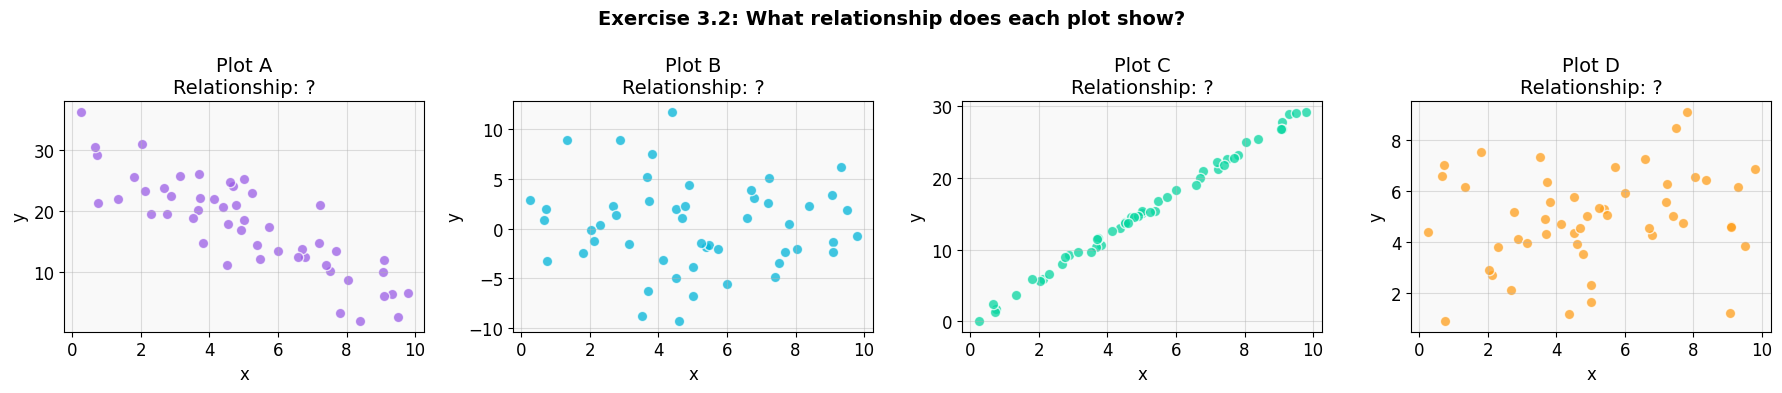

Your answers (strong positive / weak positive / strong negative / no relationship):
  Plot A: _______________
  Plot B: _______________
  Plot C: _______________
  Plot D: _______________

Reveal (run next cell to check)


In [31]:
# Exercise 3.2 — Mystery plots: identify the relationship before seeing the label
np.random.seed(7)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Exercise 3.2: What relationship does each plot show?", fontsize=14, fontweight='bold')

x_base = np.random.uniform(0, 10, 50)

mystery = [
    (x_base, -2.5*x_base + 30 + np.random.normal(0, 4, 50), "?"),
    (x_base, 0.1*x_base + np.random.normal(0, 5, 50), "?"),
    (x_base, 3*x_base + np.random.normal(0, 0.5, 50), "?"),
    (x_base, np.random.normal(5, 2, 50), "?"),
]
colors = ['#9b5de5', '#00b4d8', '#06d6a0', '#ff9f1c']

for ax, (xi, yi, label), c in zip(axes, mystery, colors):
    ax.scatter(xi, yi, color=c, alpha=0.75, s=55, edgecolors='white')
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"Plot {['A','B','C','D'][axes.tolist().index(ax)]}\nRelationship: {label}")

plt.tight_layout()
plt.show()

print("Your answers (strong positive / weak positive / strong negative / no relationship):")
print("  Plot A: _______________")
print("  Plot B: _______________")
print("  Plot C: _______________")
print("  Plot D: _______________")
print()
print("Reveal (run next cell to check)")


In [32]:
print("Answers:")
print("  Plot A: Strong NEGATIVE  (slope ≈ -2.5, tight band)")
print("  Plot B: Weak / No relationship  (near-zero slope, wide cloud)")
print("  Plot C: Strong POSITIVE  (slope ≈ 3, very tight band)")
print("  Plot D: No relationship  (flat, random scatter)")


Answers:
  Plot A: Strong NEGATIVE  (slope ≈ -2.5, tight band)
  Plot B: Weak / No relationship  (near-zero slope, wide cloud)
  Plot C: Strong POSITIVE  (slope ≈ 3, very tight band)
  Plot D: No relationship  (flat, random scatter)


---
## Module 4: Patterns in Images

The perceptron in the book learned to distinguish letters from a 20×20 pixel image — 400 numbers arranged in a grid. Let's build that intuition from scratch.

### 4.1 An Image Is Just a Grid of Numbers

Every image pixel is a number (0 = black, 255 = white, or anything between). A pattern in an image = a pattern in that number grid.

By the end of this module, you should understand three things:

1. an image can be treated as a table of numeric features
2. the *location* of a pixel matters, not just the total number of lit pixels
3. a perceptron can classify an image by assigning different weights to different pixel positions

**Why this matters:** this is the first step toward OCR, handwriting recognition, face detection, and every modern vision model. Before a model sees "a letter," it sees a grid of numbers.


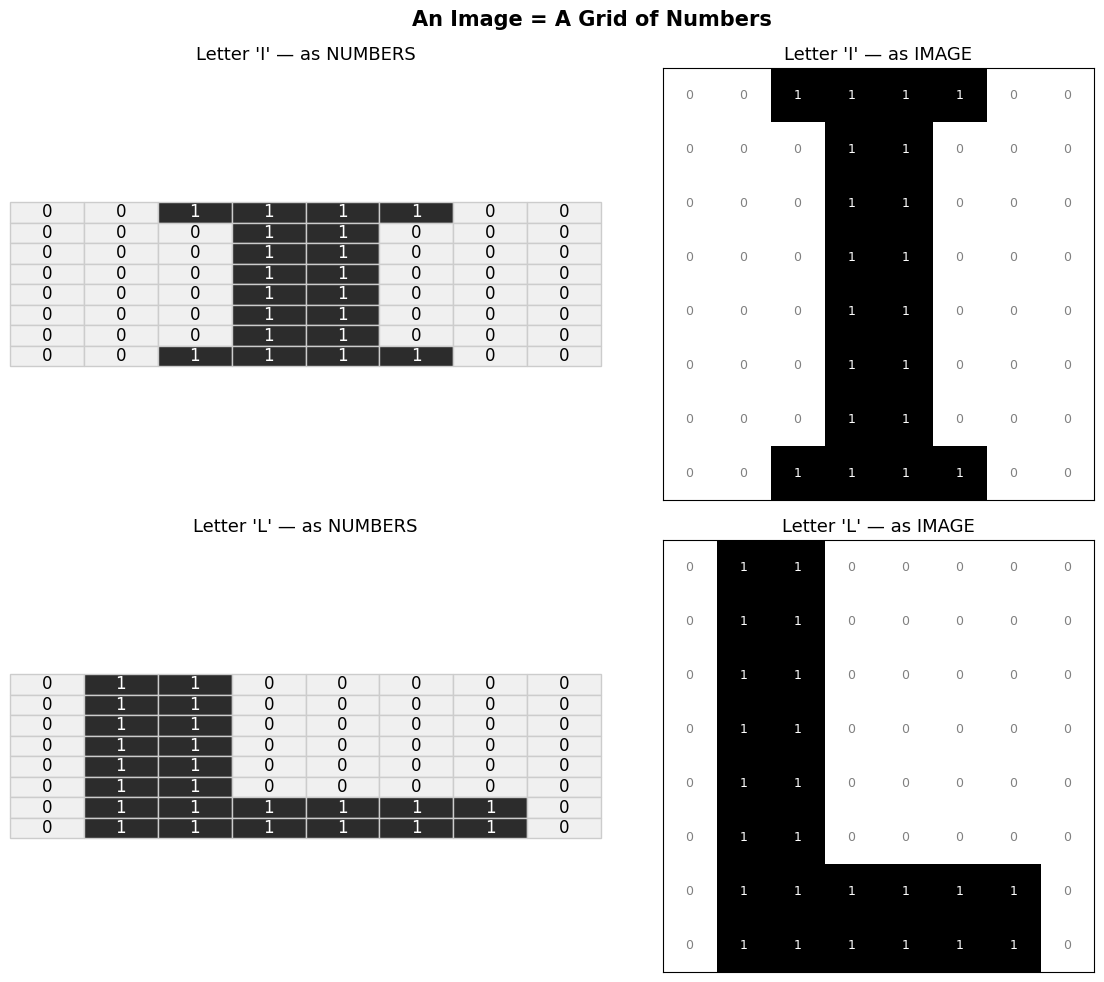

The 1s form the letter shape. The 0s are background.
'I' has 20 pixels lit. 'L' has 24 pixels lit.

Question: What's different between 'I' and 'L' in the number grid?


In [33]:
# A simple 8x8 hand-crafted "letter" — show the numbers AND the image side by side
letter_I = np.array([
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0],
], dtype=float)

letter_L = np.array([
    [0, 1, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0],
], dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("An Image = A Grid of Numbers", fontsize=15, fontweight='bold')

for row, (letter, name) in enumerate([(letter_I, "Letter 'I'"), (letter_L, "Letter 'L'")]):
    # Number grid
    ax_num = axes[row, 0]
    ax_num.axis('off')
    ax_num.set_title(f"{name} — as NUMBERS", fontsize=13)
    table_text = [[str(int(v)) for v in r] for r in letter]
    tbl = ax_num.table(cellText=table_text, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(12)
    for (r, c), cell in tbl.get_celld().items():
        v = letter[r, c] if r < 8 and c < 8 else 0
        cell.set_facecolor('#2c2c2c' if v == 1 else '#f0f0f0')
        cell.set_text_props(color='white' if v == 1 else 'black')
        cell.set_edgecolor('#cccccc')

    # Image view
    ax_img = axes[row, 1]
    ax_img.imshow(letter, cmap='gray_r', vmin=0, vmax=1)
    ax_img.set_title(f"{name} — as IMAGE", fontsize=13)
    ax_img.set_xticks([]); ax_img.set_yticks([])
    for i in range(8):
        for j in range(8):
            ax_img.text(j, i, str(int(letter[i, j])), ha='center', va='center',
                       fontsize=9, color='white' if letter[i,j]==1 else 'gray')

plt.tight_layout()
plt.show()
print("The 1s form the letter shape. The 0s are background.")
print(f"'I' has {int(letter_I.sum())} pixels lit. 'L' has {int(letter_L.sum())} pixels lit.")
print("\nQuestion: What's different between 'I' and 'L' in the number grid?")


### 4.1b From human vision to perceptron logic

When you look at the two letters, you are not merely counting how many 1s appear. You are noticing **where** they appear:

- `I` has a vertical stroke in the center and horizontal bars at the top and bottom
- `L` has a vertical stroke on the left and a horizontal stroke at the bottom

A perceptron works in the same spirit, but mechanically:

1. flatten the 8×8 image into 64 inputs
2. multiply each pixel by a weight
3. add the weighted evidence into one score
4. compare the score to a threshold (or compare several class scores)

Pixels in important locations get larger influence. A lit pixel in the right place helps the score. A lit pixel in the wrong place hurts it.


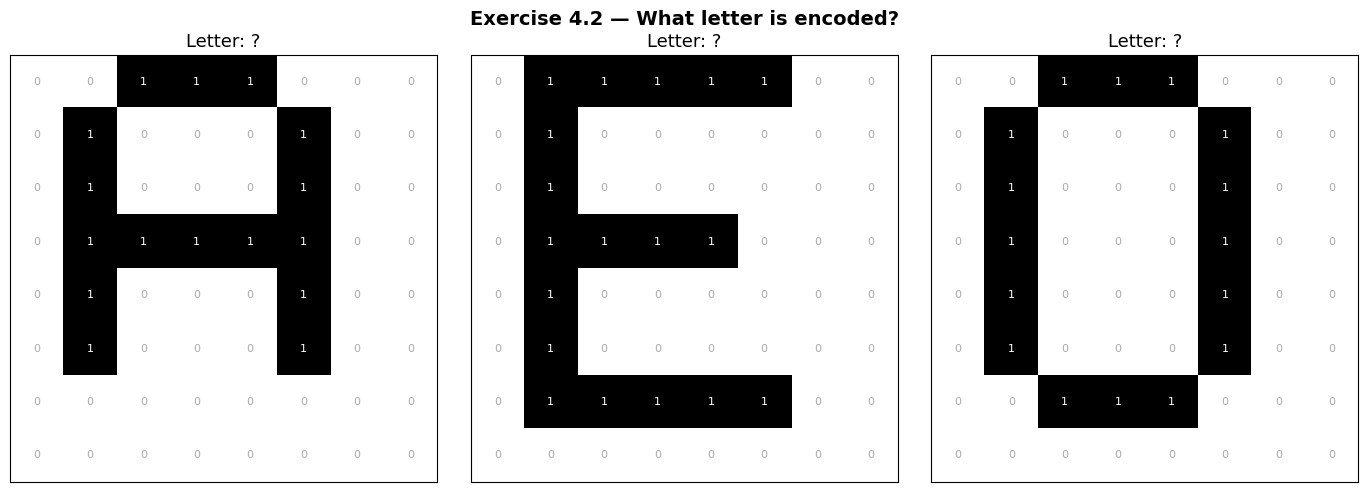

Guess the letters, then run the next cell to reveal.


In [34]:
# 4.2 Exercise: Mystery pixel grids — what letter/shape is hiding?
mystery_shapes = [
    np.array([
        [0,0,1,1,1,0,0,0],
        [0,1,0,0,0,1,0,0],
        [0,1,0,0,0,1,0,0],
        [0,1,1,1,1,1,0,0],
        [0,1,0,0,0,1,0,0],
        [0,1,0,0,0,1,0,0],
        [0,0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0,0],
    ]),  # "A" rotated?  Actually it's H
    np.array([
        [0,1,1,1,1,1,0,0],
        [0,1,0,0,0,0,0,0],
        [0,1,0,0,0,0,0,0],
        [0,1,1,1,1,0,0,0],
        [0,1,0,0,0,0,0,0],
        [0,1,0,0,0,0,0,0],
        [0,1,1,1,1,1,0,0],
        [0,0,0,0,0,0,0,0],
    ]),  # E
    np.array([
        [0,0,1,1,1,0,0,0],
        [0,1,0,0,0,1,0,0],
        [0,1,0,0,0,1,0,0],
        [0,1,0,0,0,1,0,0],
        [0,1,0,0,0,1,0,0],
        [0,1,0,0,0,1,0,0],
        [0,0,1,1,1,0,0,0],
        [0,0,0,0,0,0,0,0],
    ]),  # O
]
answers = ["H", "E", "O"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Exercise 4.2 — What letter is encoded?", fontsize=14, fontweight='bold')

for ax, shape, ans in zip(axes, mystery_shapes, answers):
    ax.imshow(shape, cmap='gray_r', vmin=0, vmax=1)
    ax.set_title("Letter: ?", fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])
    for i in range(8):
        for j in range(8):
            ax.text(j, i, str(int(shape[i,j])), ha='center', va='center',
                   fontsize=8, color='white' if shape[i,j]==1 else '#aaa')

plt.tight_layout()
plt.show()
print("Guess the letters, then run the next cell to reveal.")


In [35]:
print("Answers: H  |  E  |  O")
print()
print("Notice how YOU spotted the pattern just by looking at the pixel arrangement.")
print("The Mark I Perceptron from the book did the same — but with 400 pixels (20×20)")
print("and it LEARNED the pattern from examples, without being told the rule.")


Answers: H  |  E  |  O

Notice how YOU spotted the pattern just by looking at the pixel arrangement.
The Mark I Perceptron from the book did the same — but with 400 pixels (20×20)
and it LEARNED the pattern from examples, without being told the rule.


### 4.3 Perceptron in action — a simplified alphabet classifier

The real perceptron **learns** its weights from examples. To make the mechanism visible, we will hand-construct one simple weight pattern per letter.

The idea is straightforward:

- if a pixel should be ON for a letter, matching that pixel should help the score
- if a pixel should be OFF, turning it ON should hurt the score
- the letter with the highest total score wins

This is not yet training. It is a transparent demonstration of how a perceptron-like linear scorer turns pixels into a classification decision.


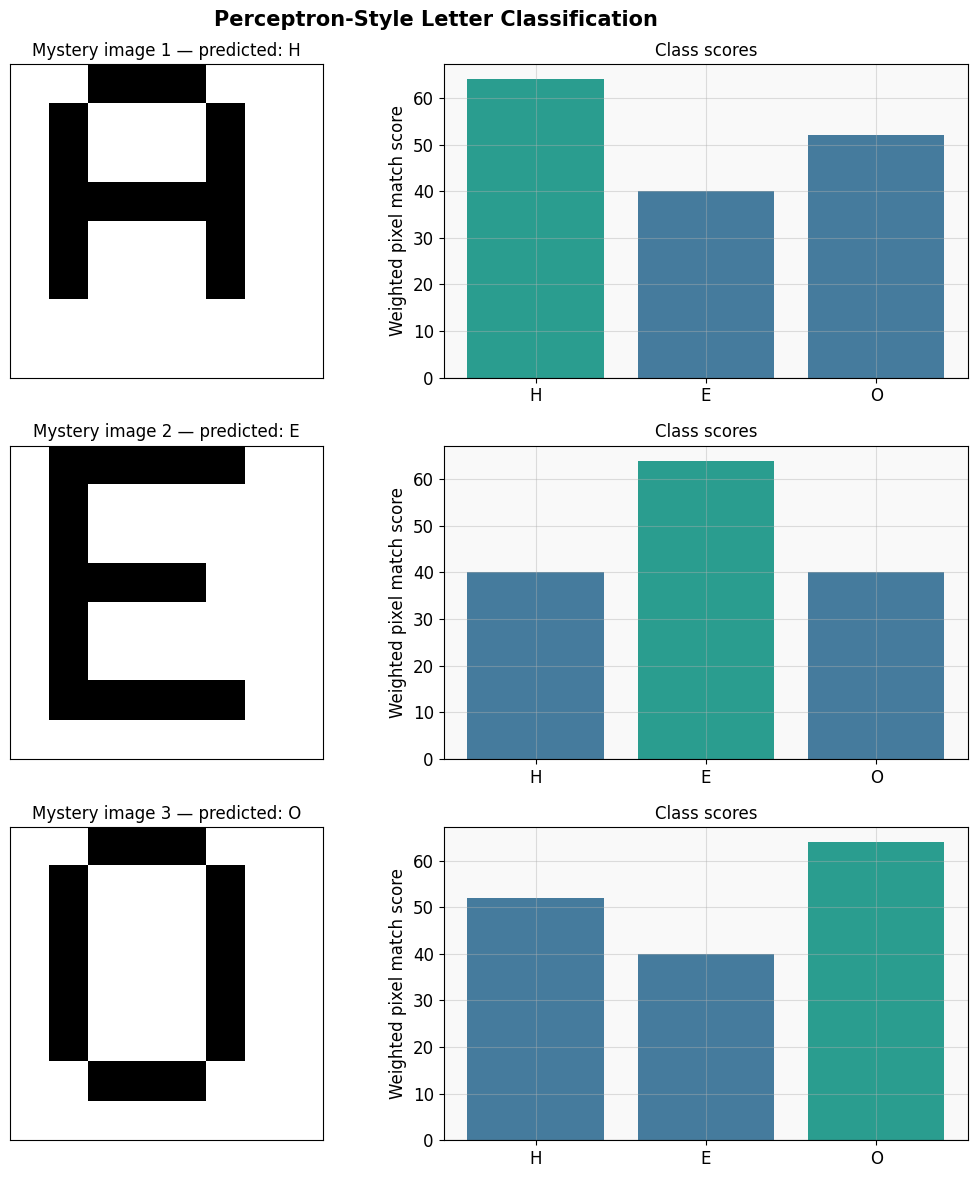

How to read these scores:
- A large positive score means the input image matches that letter's pixel pattern well.
- A lower or negative score means many pixels disagree with that letter template.

Image 1: true=H, predicted=H | scores: H=64, E=40, O=52
Image 2: true=E, predicted=E | scores: H=40, E=64, O=40
Image 3: true=O, predicted=O | scores: H=52, E=40, O=64

Important note: this is a simplified perceptron-style classifier.
The real perceptron from the book LEARNS the weights from many labeled examples
instead of us hard-coding them from the templates.


In [36]:
# 4.3 Perceptron-style letter scoring demo
# We use the three mystery letters as class templates: H, E, and O.
# A real perceptron would learn these weights from data. Here we hand-build them
# to make the scoring process visible.

letter_templates = {
    'H': mystery_shapes[0],
    'E': mystery_shapes[1],
    'O': mystery_shapes[2],
}


def signed_pixels(img):
    """Convert 0/1 pixels into -1/+1 so matches and mismatches are visible in the score."""
    return np.where(img.reshape(-1) > 0.5, 1.0, -1.0)


# Weight vector for each letter template
weights = {name: signed_pixels(template) for name, template in letter_templates.items()}

fig, axes = plt.subplots(3, 2, figsize=(11, 12))
fig.suptitle("Perceptron-Style Letter Classification", fontsize=15, fontweight='bold')
results = []

for row, (img, true_label) in enumerate(zip(mystery_shapes, answers)):
    x_vec = signed_pixels(img)
    class_scores = {name: float(np.dot(w, x_vec)) for name, w in weights.items()}
    predicted = max(class_scores, key=class_scores.get)
    results.append((true_label, predicted, class_scores))

    ax_img = axes[row, 0]
    ax_img.imshow(img, cmap='gray_r', vmin=0, vmax=1)
    ax_img.set_title(f"Mystery image {row+1} — predicted: {predicted}", fontsize=12)
    ax_img.set_xticks([]); ax_img.set_yticks([])

    ax_bar = axes[row, 1]
    labels = list(class_scores.keys())
    values = [class_scores[k] for k in labels]
    colors = ['#457b9d' if k != predicted else '#2a9d8f' for k in labels]
    ax_bar.bar(labels, values, color=colors)
    ax_bar.set_title("Class scores", fontsize=12)
    ax_bar.set_ylabel("Weighted pixel match score")
    ax_bar.axhline(0, color='black', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

print("How to read these scores:")
print("- A large positive score means the input image matches that letter's pixel pattern well.")
print("- A lower or negative score means many pixels disagree with that letter template.")
print()
for i, (true_label, predicted, class_scores) in enumerate(results, start=1):
    score_text = ', '.join([f"{k}={v:.0f}" for k, v in class_scores.items()])
    print(f"Image {i}: true={true_label}, predicted={predicted} | scores: {score_text}")

print()
print("Important note: this is a simplified perceptron-style classifier.")
print("The real perceptron from the book LEARNS the weights from many labeled examples")
print("instead of us hard-coding them from the templates.")


---
## Module 5: Patterns with Multiple Features

Real data has many features (columns). When two inputs combine to predict one output, the pattern lives in a **higher-dimensional space**. Let's build that intuition step by step.

### 5.1 From One Input to Two

With one input (x1), the pattern is a line.  
With two inputs (x1, x2), the pattern is a *surface* above a 2D plane.

Let's visualize: how does house price depend on **both** size and number of bedrooms?


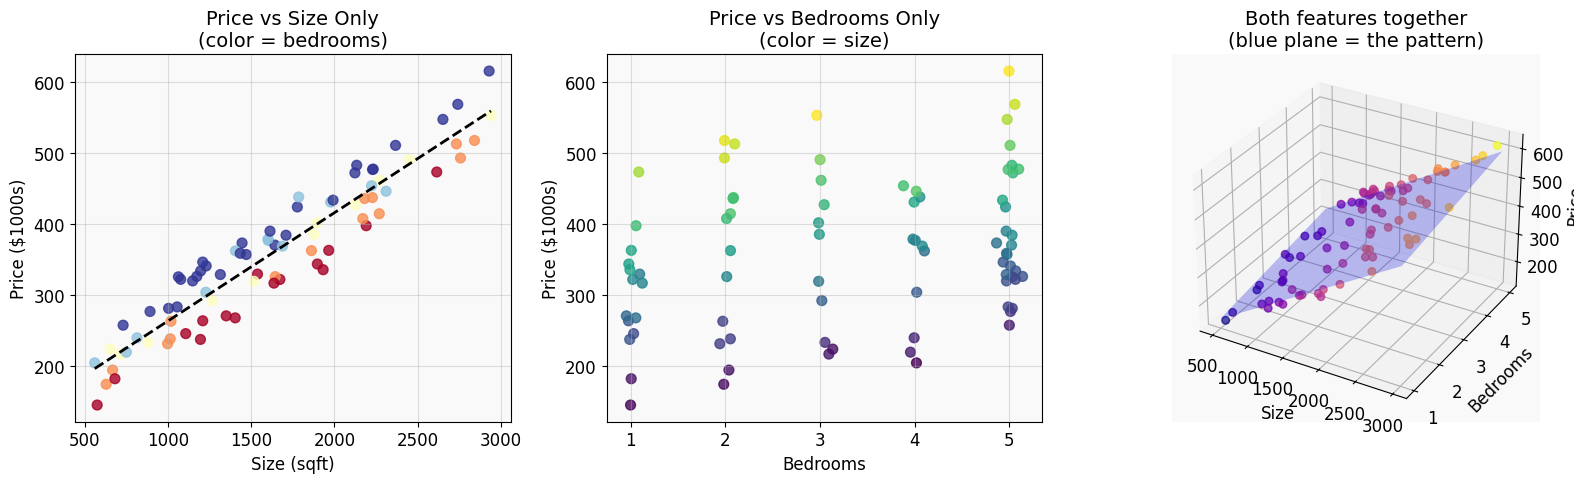

The pattern is a PLANE in 3D space — not just a line.
Finding that plane is exactly what y = w1·x1 + w2·x2 + b does.


In [37]:
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(3)
n = 80
size_sqft = np.random.uniform(500, 3000, n)          # x1: square footage
bedrooms  = np.random.randint(1, 6, n).astype(float) # x2: number of bedrooms
# True pattern: price = 0.15*size + 20*bedrooms + 50 (in $1000s) + noise
price = 0.15 * size_sqft + 20 * bedrooms + 50 + np.random.normal(0, 15, n)

fig = plt.figure(figsize=(16, 5))

# --- Panel 1: price vs size only ---
ax1 = fig.add_subplot(131)
ax1.scatter(size_sqft, price, c=bedrooms, cmap='RdYlBu', s=50, alpha=0.8)
m, b = np.polyfit(size_sqft, price, 1)
ax1.plot(np.sort(size_sqft), m*np.sort(size_sqft)+b, 'k--', lw=2)
ax1.set_xlabel("Size (sqft)"); ax1.set_ylabel("Price ($1000s)")
ax1.set_title("Price vs Size Only\n(color = bedrooms)")

# --- Panel 2: price vs bedrooms only ---
ax2 = fig.add_subplot(132)
ax2.scatter(bedrooms + np.random.normal(0, 0.05, n), price,
            c=size_sqft, cmap='viridis', s=50, alpha=0.8)
ax2.set_xlabel("Bedrooms"); ax2.set_ylabel("Price ($1000s)")
ax2.set_title("Price vs Bedrooms Only\n(color = size)")
ax2.set_xticks([1,2,3,4,5])

# --- Panel 3: 3D surface ---
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(size_sqft, bedrooms, price, c=price, cmap='plasma', s=30, alpha=0.7)
# Draw the true plane
ss = np.linspace(500, 3000, 20)
bb = np.linspace(1, 5, 20)
SS, BB = np.meshgrid(ss, bb)
PP = 0.15*SS + 20*BB + 50
ax3.plot_surface(SS, BB, PP, alpha=0.25, color='blue')
ax3.set_xlabel("Size"); ax3.set_ylabel("Bedrooms"); ax3.set_zlabel("Price")
ax3.set_title("Both features together\n(blue plane = the pattern)")

plt.tight_layout()
plt.show()
print("The pattern is a PLANE in 3D space — not just a line.")
print("Finding that plane is exactly what y = w1·x1 + w2·x2 + b does.")


### 5.2 How to read the three panels

- **Left panel:** price vs size looks noisy because bedroom count is hidden inside the color.
- **Middle panel:** price vs bedrooms also looks noisy because square footage is hidden inside the color.
- **Right panel:** once you place both features together, the pattern becomes a plane.

This is the central lesson of multivariable data: sometimes one feature looks only partly useful, but two features together reveal a much clearer structure.

**Real-life relevance:** credit risk, medical diagnosis, house pricing, and demand forecasting almost always depend on multiple features at once. Looking at a single variable in isolation can hide the true pattern.


---
## Module 6: Linear Patterns & Weights

Now we get to the core math from the chapter. The pattern `y = w1·x1 + w2·x2` is defined by its **weights**. Let's understand what different weights mean visually.

### 6.1 What Do the Weights Control?

The weight says: *"how much does this input matter?"*  
A big weight → that input strongly influences the output.  
A negative weight → that input pulls the output down.

**Why this matters:** once you understand weights, you understand what a linear model is really storing. It is storing a compact summary of which inputs matter more, which matter less, and which push the answer up or down.


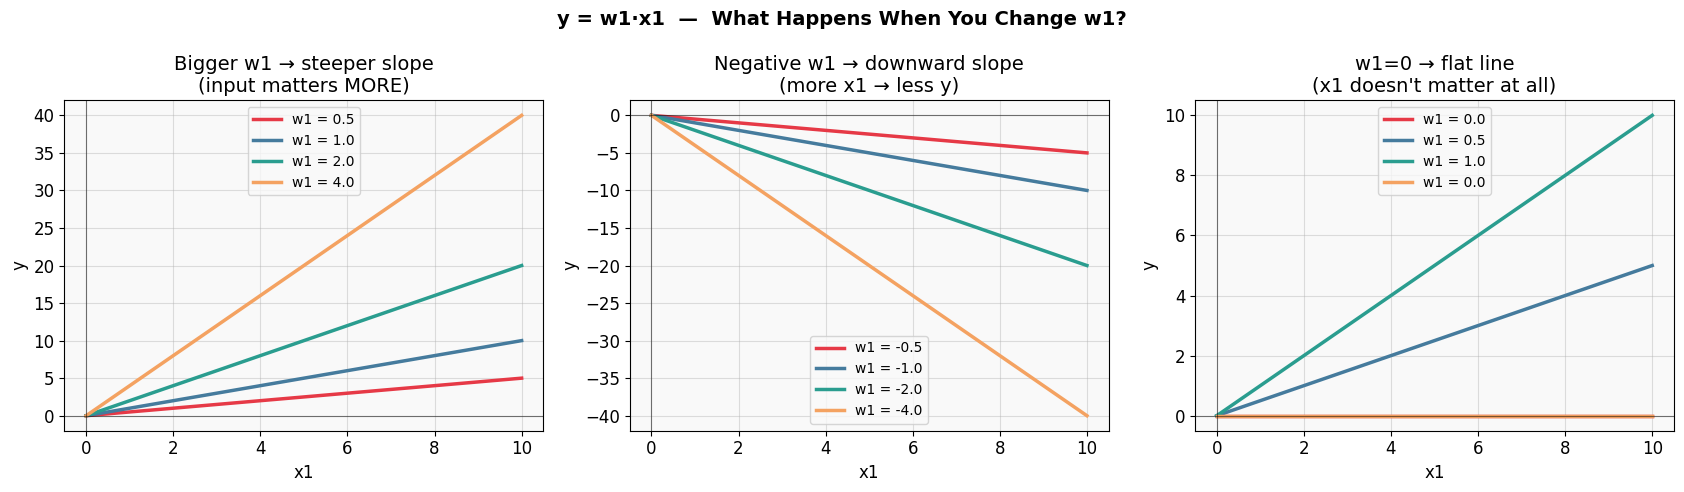

In [38]:
# Interactive demo: how changing weights changes the pattern
x1_vals = np.linspace(0, 10, 100)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("y = w1·x1  —  What Happens When You Change w1?", fontsize=14, fontweight='bold')

weight_sets = [
    ([0.5, 1.0, 2.0, 4.0], "Bigger w1 → steeper slope\n(input matters MORE)", "positive"),
    ([-0.5, -1.0, -2.0, -4.0], "Negative w1 → downward slope\n(more x1 → less y)", "negative"),
    ([0.0, 0.5, 1.0, 0.0], "w1=0 → flat line\n(x1 doesn't matter at all)", "zero"),
]
colors_w = ['#e63946', '#457b9d', '#2a9d8f', '#f4a261']

for ax, (weights, title, _) in zip(axes, weight_sets):
    for w, c in zip(weights, colors_w):
        y = w * x1_vals
        ax.plot(x1_vals, y, color=c, linewidth=2.5, label=f"w1 = {w}")
    ax.set_xlabel("x1"); ax.set_ylabel("y")
    ax.set_title(title)
    ax.legend(fontsize=10)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()


### 6.2 Why this exercise exists

The weight guessing game is not busywork. It teaches the most important inverse problem in machine learning:

> **You can see the examples, but the rule is hidden. Can you recover the rule from the data?**

That is exactly what a learning algorithm does.

A good strategy is:

1. compare rows where `x2` stays the same and only `x1` changes
2. compare rows where `x1` stays the same and only `x2` changes
3. estimate how much `y` changes per unit change in each input
4. test your guessed weights on several rows, not just one

Mini-example:

- if changing `x1` from 2 to 3 raises `y` by about 4 while `x2` stays fixed, then `w1` is probably near 4
- if changing `x2` by 1 raises `y` by about 1 while `x1` stays fixed, then `w2` is probably near 1

So the goal is not just to get the answer. The goal is to practice thinking like the algorithm.


In [39]:
# Exercise 6.2: Weight guessing game
# Each dataset was generated by a formula y = w1*x1 + w2*x2
# Your job: find w1 and w2

np.random.seed(99)

def make_dataset(w1, w2, b=0, n=8, noise=0):
    x1 = np.random.randint(0, 6, n).astype(float)
    x2 = np.random.randint(0, 6, n).astype(float)
    y  = w1*x1 + w2*x2 + b + np.random.normal(0, noise, n)
    return x1, x2, np.round(y, 1)

datasets = [
    (make_dataset(3, 1),   "Dataset 1",  "y = ?·x1 + ?·x2"),
    (make_dataset(1, 4),   "Dataset 2",  "y = ?·x1 + ?·x2"),
    (make_dataset(2, -1),  "Dataset 3",  "y = ?·x1 + ?·x2  (one weight is negative!)"),
    (make_dataset(0, 5),   "Dataset 4",  "y = ?·x1 + ?·x2  (one input is a red herring)"),
]

for (x1, x2, y), name, prompt in datasets:
    print(f"\n{'='*55}")
    print(f"  {name}:  {prompt}")
    print(f"{'='*55}")
    print(f"  {'x1':>5} {'x2':>5} {'y':>7}")
    for a, b, c in zip(x1, x2, y):
        print(f"  {int(a):>5} {int(b):>5} {c:>7.1f}")



  Dataset 1:  y = ?·x1 + ?·x2
     x1    x2       y
      1     5     8.0
      3     4    13.0
      1     1     4.0
      0     3     3.0
      1     1     4.0
      0     1     1.0
      2     0     6.0
      4     5    17.0

  Dataset 2:  y = ?·x1 + ?·x2
     x1    x2       y
      3     5    23.0
      5     1     9.0
      4     3    16.0
      4     3    16.0
      1     2     9.0
      1     2     9.0
      1     3    13.0
      0     5    20.0

  Dataset 3:  y = ?·x1 + ?·x2  (one weight is negative!)
     x1    x2       y
      1     0     2.0
      0     5    -5.0
      3     0     6.0
      0     2    -2.0
      5     3     7.0
      3     2     4.0
      3     3     3.0
      2     2     2.0

  Dataset 4:  y = ?·x1 + ?·x2  (one input is a red herring)
     x1    x2       y
      3     4    20.0
      3     5    25.0
      5     3    15.0
      2     1     5.0
      3     5    25.0
      5     5    25.0
      0     0     0.0
      3     0     0.0


In [40]:
# Reveal answers
print("Answers:")
print("  Dataset 1: y = 3·x1 + 1·x2")
print("  Dataset 2: y = 1·x1 + 4·x2")
print("  Dataset 3: y = 2·x1 - 1·x2  ← negative weight!")
print("  Dataset 4: y = 0·x1 + 5·x2  ← x1 is irrelevant (weight = 0)")
print()
print("Why this game matters:")
print("  You were given outputs and had to infer the hidden rule.")
print("  That is exactly the learning problem a linear model solves automatically.")
print()
print("A useful solving strategy is to compare rows where one feature stays the same")
print("and watch how y changes when the other feature changes.")
print("That lets you estimate the weight of each input separately.")


Answers:
  Dataset 1: y = 3·x1 + 1·x2
  Dataset 2: y = 1·x1 + 4·x2
  Dataset 3: y = 2·x1 - 1·x2  ← negative weight!
  Dataset 4: y = 0·x1 + 5·x2  ← x1 is irrelevant (weight = 0)

Why this game matters:
  You were given outputs and had to infer the hidden rule.
  That is exactly the learning problem a linear model solves automatically.

A useful solving strategy is to compare rows where one feature stays the same
and watch how y changes when the other feature changes.
That lets you estimate the weight of each input separately.


---
## Module 7: Drawing the Boundary

So far we've predicted a *number* (regression). Now we predict a *category* (classification). The pattern is no longer a line through points — it's a **line that separates groups**.

This is exactly the perceptron's job from the chapter: find the boundary that separates "obese" from "not-obese" in weight-height space.

### 7.1 Seeing the Boundary

A classification boundary has a different meaning from a regression line:

- the line itself is the set of "tie" points where the model is undecided
- one side of the line is classified as one class
- the other side is classified as the other class
- a bad boundary is not just a bad line — it puts many points on the wrong side

So when you look at the next figure, do not ask "Does the line go through the data?"
Ask instead: **"Does the line separate the two groups with as few mistakes as possible?"**


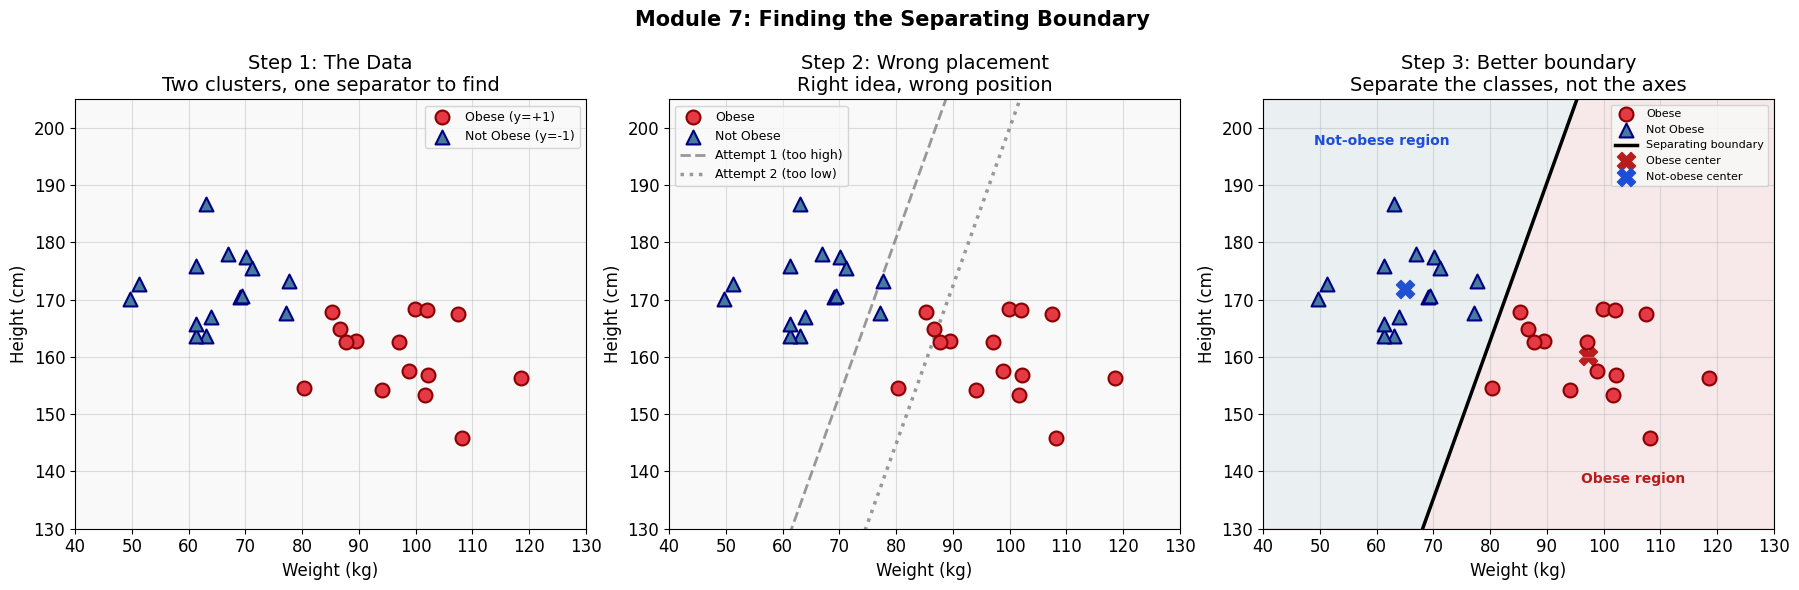

Not-obese center ≈ (65.1 kg, 171.9 cm)
Obese center     ≈ (97.3 kg, 160.2 cm)

The black boundary is placed between the two cluster centers.
Points above the line are classified as Not Obese; points below the line as Obese.
This is closer to what a perceptron is trying to learn: a separator between groups,
not a line drawn through the middle of the points.


In [18]:
# Recreate the book's weight-height / obese classification example
np.random.seed(42)

# Not-obese: lower weight, taller (triangles, y=-1)
weight_no  = np.random.normal(65, 8, 15)
height_no  = np.random.normal(175, 8, 15)

# Obese: higher weight, shorter (circles, y=+1)
weight_yes = np.random.normal(100, 10, 15)
height_yes = np.random.normal(160, 8, 15)

# Use the class centroids to build a more justifiable separating line.
# The boundary is the set of points equally 'close' to both class centers.
mean_no = np.array([weight_no.mean(), height_no.mean()])
mean_yes = np.array([weight_yes.mean(), height_yes.mean()])
midpoint = (mean_no + mean_yes) / 2
normal = mean_yes - mean_no  # points toward the obese cluster

w_range = np.linspace(40, 130, 300)
slope = -normal[0] / normal[1]
intercept = midpoint[1] - slope * midpoint[0]
boundary_y = slope * w_range + intercept

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Module 7: Finding the Separating Boundary', fontsize=15, fontweight='bold')

# ---- Plot 1: Raw data, no boundary ----
ax = axes[0]
ax.scatter(weight_yes, height_yes, marker='o', s=100, color='#e63946',
           edgecolors='darkred', linewidth=1.5, label='Obese (y=+1)', zorder=5)
ax.scatter(weight_no, height_no, marker='^', s=100, color='#457b9d',
           edgecolors='navy', linewidth=1.5, label='Not Obese (y=-1)', zorder=5)
ax.set_xlabel('Weight (kg)'); ax.set_ylabel('Height (cm)')
ax.set_title('Step 1: The Data\nTwo clusters, one separator to find')
ax.legend(fontsize=9)

# ---- Plot 2: Two wrong boundary attempts ----
ax = axes[1]
ax.scatter(weight_yes, height_yes, marker='o', s=100, color='#e63946',
           edgecolors='darkred', linewidth=1.5, label='Obese', zorder=5)
ax.scatter(weight_no, height_no, marker='^', s=100, color='#457b9d',
           edgecolors='navy', linewidth=1.5, label='Not Obese', zorder=5)
ax.plot(w_range, boundary_y + 18, '--', color='gray', lw=2, alpha=0.8,
        label='Attempt 1 (too high)')
ax.plot(w_range, boundary_y - 18, ':', color='gray', lw=2.5, alpha=0.8,
        label='Attempt 2 (too low)')
ax.set_xlabel('Weight (kg)'); ax.set_ylabel('Height (cm)')
ax.set_title('Step 2: Wrong placement\nRight idea, wrong position')
ax.legend(fontsize=9)

# ---- Plot 3: Better boundary ----
ax = axes[2]
ax.scatter(weight_yes, height_yes, marker='o', s=100, color='#e63946',
           edgecolors='darkred', linewidth=1.5, label='Obese', zorder=5)
ax.scatter(weight_no, height_no, marker='^', s=100, color='#457b9d',
           edgecolors='navy', linewidth=1.5, label='Not Obese', zorder=5)
ax.plot(w_range, boundary_y, '-', color='black', lw=2.5, label='Separating boundary', zorder=4)
ax.scatter(mean_yes[0], mean_yes[1], marker='X', s=170, color='#b91c1c', label='Obese center')
ax.scatter(mean_no[0], mean_no[1], marker='X', s=170, color='#1d4ed8', label='Not-obese center')
ax.fill_between(w_range, boundary_y, 205, alpha=0.08, color='#457b9d')
ax.fill_between(w_range, 130, boundary_y, alpha=0.08, color='#e63946')
ax.text(49, 197, 'Not-obese region', color='#1d4ed8', fontsize=10, fontweight='bold')
ax.text(96, 138, 'Obese region', color='#b91c1c', fontsize=10, fontweight='bold')
ax.set_xlabel('Weight (kg)'); ax.set_ylabel('Height (cm)')
ax.set_title('Step 3: Better boundary\nSeparate the classes, not the axes')
ax.legend(fontsize=8, loc='upper right')

for ax in axes:
    ax.set_xlim(40, 130)
    ax.set_ylim(130, 205)

plt.tight_layout()
plt.show()

print(f'Not-obese center ≈ ({mean_no[0]:.1f} kg, {mean_no[1]:.1f} cm)')
print(f'Obese center     ≈ ({mean_yes[0]:.1f} kg, {mean_yes[1]:.1f} cm)')
print()
print('The black boundary is placed between the two cluster centers.')
print('Points above the line are classified as Not Obese; points below the line as Obese.')
print('This is closer to what a perceptron is trying to learn: a separator between groups,')
print('not a line drawn through the middle of the points.')


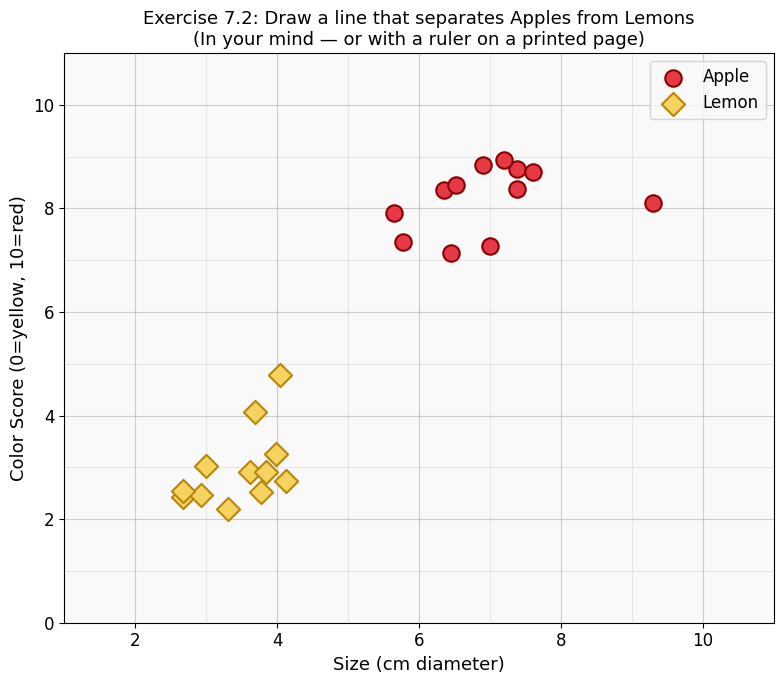

Questions to think about:
  1. Is one line enough, or do you need a curve?
  2. Are the clusters cleanly separable?
  3. Which feature (size or color) is more useful on its own?


In [19]:
# Exercise 7.2: Draw your own boundary — classify fruit by color and size
np.random.seed(12)

# Apples: medium size, red/high color-score
apple_size  = np.random.normal(7, 0.8, 12)
apple_color = np.random.normal(8, 0.7, 12)

# Lemons: smaller, yellow/low color-score
lemon_size  = np.random.normal(4, 0.6, 12)
lemon_color = np.random.normal(3, 0.8, 12)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(apple_size, apple_color, marker='o', s=140, color='#e63946',
           edgecolors='darkred', linewidth=1.5, label='Apple', zorder=5)
ax.scatter(lemon_size, lemon_color, marker='D', s=140, color='#f4d35e',
           edgecolors='#b8860b', linewidth=1.5, label='Lemon', zorder=5)

ax.set_xlabel("Size (cm diameter)", fontsize=13)
ax.set_ylabel("Color Score (0=yellow, 10=red)", fontsize=13)
ax.set_title("Exercise 7.2: Draw a line that separates Apples from Lemons\n"
             "(In your mind — or with a ruler on a printed page)", fontsize=13)
ax.legend(fontsize=12)
ax.set_xlim(1, 11); ax.set_ylim(0, 11)

# Faint grid to help draw
for v in range(1, 11):
    ax.axvline(v, color='gray', alpha=0.15, lw=0.8)
    ax.axhline(v, color='gray', alpha=0.15, lw=0.8)

plt.tight_layout()
plt.show()
print("Questions to think about:")
print("  1. Is one line enough, or do you need a curve?")
print("  2. Are the clusters cleanly separable?")
print("  3. Which feature (size or color) is more useful on its own?")


---
## Module 8: When Patterns Hide — Noise and Harder Cases

Real data is messy. Patterns don't come clean. This final module builds resilience: the ability to find a signal through the noise.

### 8.1 Signal vs. Noise

The same underlying pattern, buried under increasing amounts of noise.

In the next figure, two different lines appear in every panel:

- **True pattern:** the hidden rule that actually generated the data
- **Estimated pattern:** the line recovered from the noisy sample using a fitting method (`np.polyfit` here)

Those two are not the same thing.
The true pattern is what reality is doing.
The estimated pattern is what the learner can infer from imperfect observations.

At low noise, the estimate almost overlaps the truth because the signal is strong.
At high noise, the estimate drifts because the learner is seeing a messier version of reality.


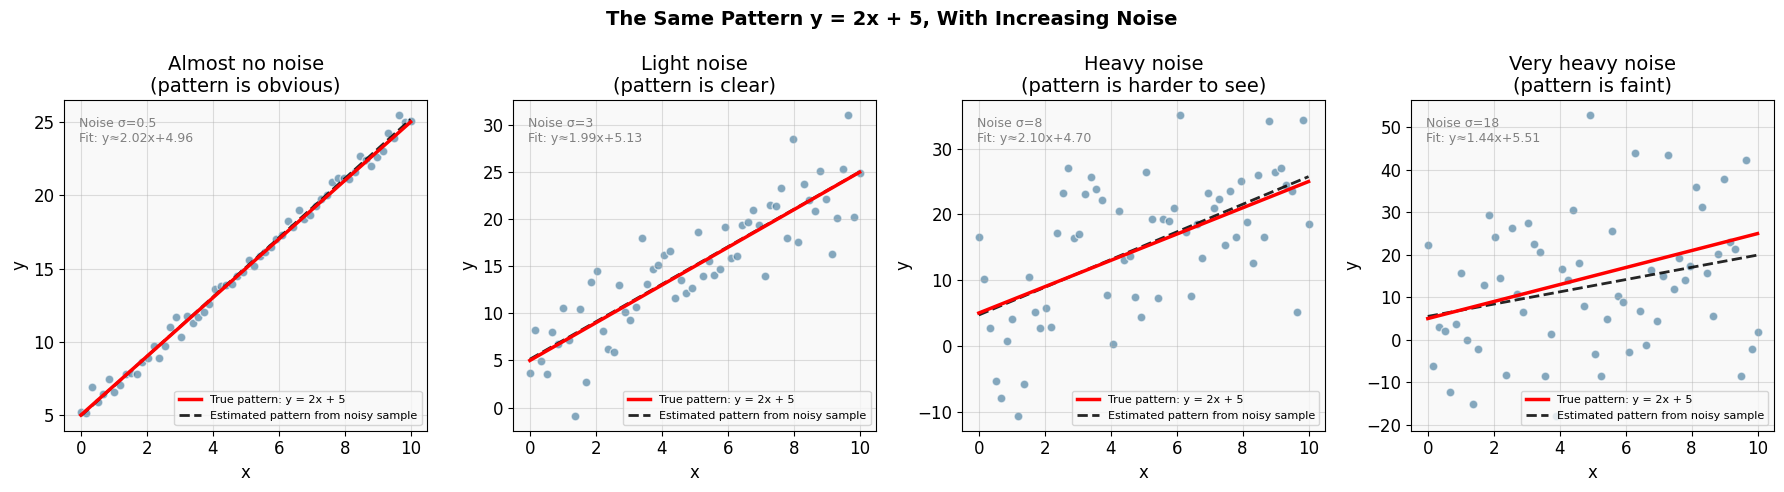

True pattern = the hidden rule used to generate the data: y = 2x + 5.
Estimated pattern = the best-fit line recovered only from the noisy observations.

Why the two lines overlap at low noise:
  The random deviations are small, so the sample still reflects the true rule clearly.
Why they separate more at high noise:
  The sample gets distorted, so the fitted line is pulled away from the underlying rule.

 Noise σ    Estimated slope    Estimated intercept
----------------------------------------------------
     0.5              2.022                  4.958
     3.0              1.989                  5.128
     8.0              2.105                  4.703
    18.0              1.443                  5.509


In [20]:
np.random.seed(5)
x = np.linspace(0, 10, 60)
true_pattern = 2*x + 5   # y = 2x + 5 is the ground truth

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('The Same Pattern y = 2x + 5, With Increasing Noise', fontsize=14, fontweight='bold')

noise_levels = [0.5, 3, 8, 18]
titles = [
    'Almost no noise\n(pattern is obvious)',
    'Light noise\n(pattern is clear)',
    'Heavy noise\n(pattern is harder to see)',
    'Very heavy noise\n(pattern is faint)',
]
fit_rows = []

for ax, noise, title in zip(axes, noise_levels, titles):
    y_noisy = true_pattern + np.random.normal(0, noise, len(x))
    ax.scatter(x, y_noisy, color='#457b9d', alpha=0.65, s=40, edgecolors='white')
    ax.plot(x, true_pattern, 'r-', linewidth=2.5, label='True pattern: y = 2x + 5', zorder=5)
    m, b = np.polyfit(x, y_noisy, 1)
    est = m*x + b
    ax.plot(x, est, 'k--', linewidth=2, label='Estimated pattern from noisy sample', alpha=0.85)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.text(0.04, 0.95, f'Noise σ={noise}\nFit: y≈{m:.2f}x+{b:.2f}',
            transform=ax.transAxes, fontsize=9, va='top', color='gray')
    fit_rows.append((noise, m, b))

plt.tight_layout()
plt.show()

print('True pattern = the hidden rule used to generate the data: y = 2x + 5.')
print('Estimated pattern = the best-fit line recovered only from the noisy observations.')
print()
print('Why the two lines overlap at low noise:')
print('  The random deviations are small, so the sample still reflects the true rule clearly.')
print('Why they separate more at high noise:')
print('  The sample gets distorted, so the fitted line is pulled away from the underlying rule.')
print()
print('{:>8} {:>18} {:>22}'.format('Noise σ', 'Estimated slope', 'Estimated intercept'))
print('-' * 52)
for noise, m, b in fit_rows:
    print(f'{noise:>8.1f} {m:>18.3f} {b:>22.3f}')


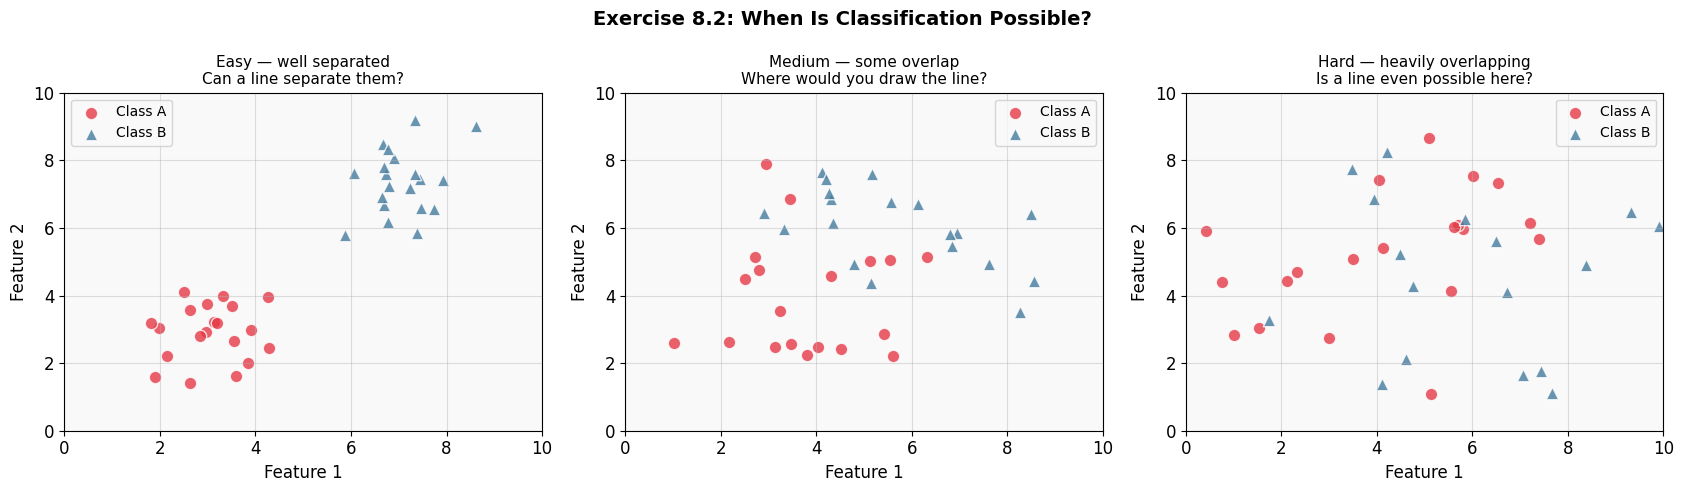

Discussion:
  Easy:   A straight line clearly separates the clusters → linearly separable
  Medium: A line works but will make some mistakes — that's okay, we minimize errors
  Hard:   The classes are so mixed that no line helps — the perceptron cannot learn this

This is the fundamental limitation the book describes: the perceptron only works
when the data is (approximately) linearly separable.


In [21]:
# Exercise 8.2: Can you classify when classes overlap?
np.random.seed(21)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Exercise 8.2: When Is Classification Possible?", fontsize=14, fontweight='bold')

configs = [
    (dict(loc=[3,3], scale=0.8), dict(loc=[7,7], scale=0.8),  "Easy — well separated\nCan a line separate them?"),
    (dict(loc=[4,4], scale=1.5), dict(loc=[6,6], scale=1.5),  "Medium — some overlap\nWhere would you draw the line?"),
    (dict(loc=[5,5], scale=2.5), dict(loc=[5,5], scale=2.5),  "Hard — heavily overlapping\nIs a line even possible here?"),
]

for ax, (cfg_a, cfg_b, title) in zip(axes, configs):
    A = np.random.normal(loc=cfg_a['loc'], scale=cfg_a['scale'], size=(20, 2))
    B = np.random.normal(loc=cfg_b['loc'], scale=cfg_b['scale'], size=(20, 2))
    ax.scatter(A[:,0], A[:,1], marker='o', s=80, color='#e63946', alpha=0.8,
               edgecolors='white', label='Class A')
    ax.scatter(B[:,0], B[:,1], marker='^', s=80, color='#457b9d', alpha=0.8,
               edgecolors='white', label='Class B')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=10)
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()
print("Discussion:")
print("  Easy:   A straight line clearly separates the clusters → linearly separable")
print("  Medium: A line works but will make some mistakes — that's okay, we minimize errors")
print("  Hard:   The classes are so mixed that no line helps — the perceptron cannot learn this")
print()
print("This is the fundamental limitation the book describes: the perceptron only works")
print("when the data is (approximately) linearly separable.")


---
## Final Exercise: End-to-End Pattern Hunt

You've built all the skills. Now use them together on a mystery dataset.

**The scenario:** You're helping a fruit-sorting facility that packs export orders for two supermarket chains. One chain ordered **premium mangoes**, the other ordered **kiwis**. Each fruit is measured by an optical sensor and a scale before being routed into the correct crate.

A sorting mistake has a real cost:

- sending a kiwi into a mango crate reduces product quality and customer trust
- sending a mango into a kiwi crate loses revenue because mangoes are the premium fruit
- borderline fruits may need **manual inspection** instead of automatic classification

You have measurements of 50 fruits and a label (Mango vs. Kiwi). Your job is to:

1. inspect the training data
2. describe the pattern in words
3. predict the label for 5 new fruits
4. identify which fruit is too close to the boundary to trust automatically


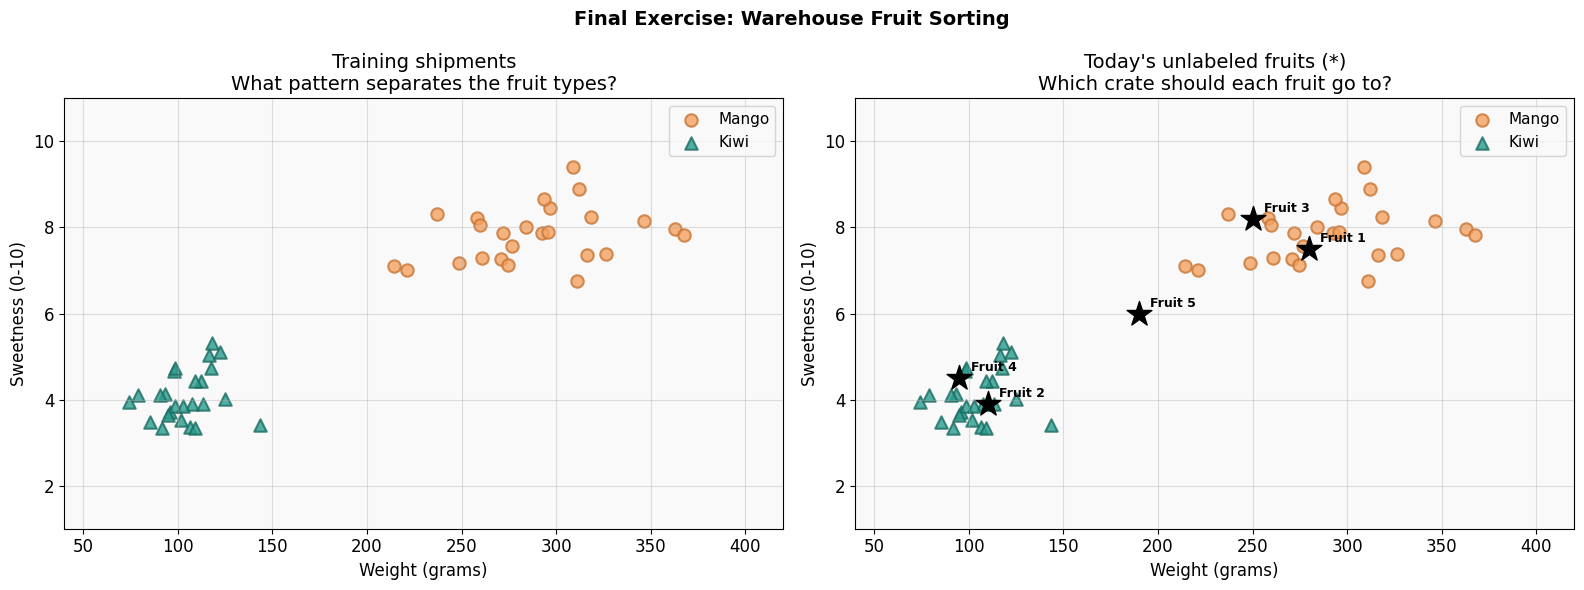

Your task:
  1. Describe the pattern in one sentence.
  2. Predict Mango or Kiwi for each new fruit.
  3. Say which fruit is borderline and may need manual inspection.

  Fruit 1: weight=280.0g, sweetness=7.5  ->  ___________
  Fruit 2: weight=110.0g, sweetness=3.9  ->  ___________
  Fruit 3: weight=250.0g, sweetness=8.2  ->  ___________
  Fruit 4: weight=95.0g, sweetness=4.5  ->  ___________
  Fruit 5: weight=190.0g, sweetness=6.0  ->  ___________


In [22]:
np.random.seed(77)

# Generate fruit data
# Mango: heavier, sweeter
mango_weight = np.random.normal(300, 40, 25)
mango_sweetness = np.random.normal(8, 0.8, 25)

# Kiwi: lighter, less sweet
kiwi_weight = np.random.normal(100, 15, 25)
kiwi_sweetness = np.random.normal(4, 0.7, 25)

# 5 new unlabeled fruits to classify
new_fruits = np.array([
    [280, 7.5],
    [110, 3.9],
    [250, 8.2],
    [95, 4.5],
    [190, 6.0],  # intentionally borderline
])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Final Exercise: Warehouse Fruit Sorting', fontsize=14, fontweight='bold')

for ax in axes:
    ax.scatter(mango_weight, mango_sweetness, marker='o', s=80, color='#f4a261',
               edgecolors='#c77534', linewidth=1.5, label='Mango', alpha=0.8)
    ax.scatter(kiwi_weight, kiwi_sweetness, marker='^', s=80, color='#2a9d8f',
               edgecolors='#1a6b61', linewidth=1.5, label='Kiwi', alpha=0.8)
    ax.set_xlabel('Weight (grams)', fontsize=12)
    ax.set_ylabel('Sweetness (0-10)', fontsize=12)
    ax.legend(fontsize=11)
    ax.set_xlim(40, 420); ax.set_ylim(1, 11)

axes[0].set_title('Training shipments\nWhat pattern separates the fruit types?')
axes[1].set_title("Today's unlabeled fruits (*)\nWhich crate should each fruit go to?")

for i, (w, s) in enumerate(new_fruits):
    axes[1].scatter(w, s, marker='*', s=350, color='black', zorder=10)
    axes[1].annotate(f'Fruit {i+1}', (w, s), textcoords='offset points',
                     xytext=(8, 5), fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('Your task:')
print('  1. Describe the pattern in one sentence.')
print('  2. Predict Mango or Kiwi for each new fruit.')
print('  3. Say which fruit is borderline and may need manual inspection.')
print()
for i, (w, s) in enumerate(new_fruits, start=1):
    print(f'  Fruit {i}: weight={w}g, sweetness={s}  ->  ___________')


Suggested boundary: score = 0.02×weight + 0.8×sweetness − 8.8
  if score > 0 → Mango
  if score < 0 → Kiwi
  if score is very close to 0 → Borderline, inspect manually

  Fruit 1: score = 2.80  →  Mango
  Fruit 2: score = -3.48  →  Kiwi
  Fruit 3: score = 2.76  →  Mango
  Fruit 4: score = -3.30  →  Kiwi
  Fruit 5: score = -0.20  →  Borderline / manual check


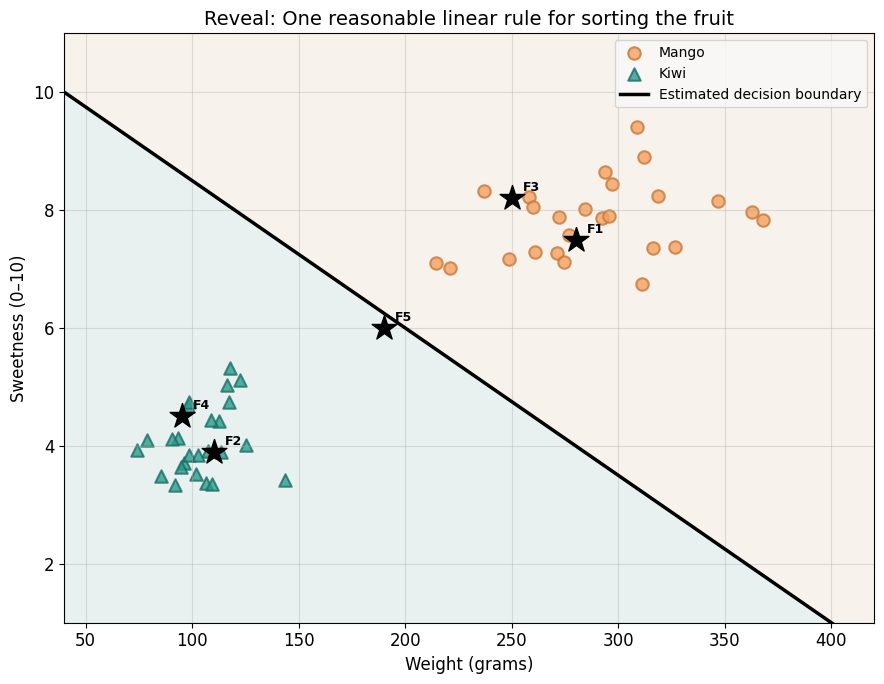


Why Fruit 5 is interesting:
  It lands very close to the boundary, so small measurement changes could flip its class.
That is exactly what uncertainty looks like in a real pattern-recognition system.
The boundary is an estimated rule from the visible cluster structure — not a unique law of nature.


In [23]:
# Reveal: use a simple hand-drawn linear boundary to classify
# This rule is based on the visible separation in the plot.
# Weight is measured in grams and sweetness on a 0-10 scale, so we scale them differently.
# Score > 0  -> Mango region
# Score < 0  -> Kiwi region

def fruit_score(weight, sweetness):
    return 0.02 * weight + 0.8 * sweetness - 8.8

w_range = np.linspace(40, 420, 300)
boundary = (8.8 - 0.02 * w_range) / 0.8

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(mango_weight, mango_sweetness, marker='o', s=80, color='#f4a261',
           edgecolors='#c77534', linewidth=1.5, label='Mango', alpha=0.8)
ax.scatter(kiwi_weight, kiwi_sweetness, marker='^', s=80, color='#2a9d8f',
           edgecolors='#1a6b61', linewidth=1.5, label='Kiwi', alpha=0.8)
ax.plot(w_range, boundary, color='black', linewidth=2.5, label='Estimated decision boundary')
ax.fill_between(w_range, boundary, 11, color='#f4a261', alpha=0.08)
ax.fill_between(w_range, 1, boundary, color='#2a9d8f', alpha=0.08)
ax.set_xlim(40, 420); ax.set_ylim(1, 11)
ax.set_xlabel('Weight (grams)')
ax.set_ylabel('Sweetness (0–10)')
ax.set_title('Reveal: One reasonable linear rule for sorting the fruit')

print("Suggested boundary: score = 0.02×weight + 0.8×sweetness − 8.8")
print("  if score > 0 → Mango")
print("  if score < 0 → Kiwi")
print("  if score is very close to 0 → Borderline, inspect manually")
print()

for i, (w, s) in enumerate(new_fruits, start=1):
    score = fruit_score(w, s)
    if abs(score) < 0.35:
        label = 'Borderline / manual check'
    elif score > 0:
        label = 'Mango'
    else:
        label = 'Kiwi'
    ax.scatter(w, s, marker='*', s=350, color='black', zorder=10)
    ax.annotate(f"F{i}", (w, s), textcoords='offset points', xytext=(8, 5), fontsize=9, fontweight='bold')
    print(f"  Fruit {i}: score = {score:.2f}  →  {label}")

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print()
print("Why Fruit 5 is interesting:")
print("  It lands very close to the boundary, so small measurement changes could flip its class.")
print("That is exactly what uncertainty looks like in a real pattern-recognition system.")
print("The boundary is an estimated rule from the visible cluster structure — not a unique law of nature.")


---
## Summary & What's Next

### What You've Learned to Do

| Skill | Module |
|-------|--------|
| Spot patterns in number sequences | 1 |
| Identify relationships in real-world situations | 1 |
| Read a scatter plot's story | 3 |
| Decode patterns in pixel grids (images) | 4 |
| See a perceptron-style image classifier score letters | 4 |
| Work with two-feature data in 3D | 5 |
| Find weights in `y = w1·x1 + w2·x2` | 6 |
| Explain why a classification boundary works | 7 |
| Separate true pattern from estimated pattern under noise | 8 |
| Handle ambiguity in a realistic classification task | Final Exercise |

### The Core Mental Model

```
Data → Look for patterns → Express as y = w1·x1 + w2·x2 + b → Predict new values
```

This is machine learning. The only difference between what you did here and what a neural network does is **scale** (millions of inputs, millions of weights) and **automation** (an algorithm adjusts the weights instead of you guessing them).

### What Comes Next
- **Chapter 2:** How does an algorithm *automatically* find the weights?  
- **Chapter 3:** What happens when the data isn't linearly separable?  
- **Later:** Multiple layers of neurons — deep learning — for patterns a single line can never capture.

---
*Curriculum based on Chapter 1 of "Why Machines Learn" (Anil Ananthaswamy)*
